In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.cm as cm
from matplotlib.colors import LogNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pyhdf.SD import SD, SDC
import math
import pprint

import warnings
warnings.filterwarnings("ignore")

In [2]:
# attrs = cer.attributes()
# print("Long name:", attrs.get('long_name'))
# print("Units:", attrs.get('units'))
# print("Valid range:", attrs.get('valid_range'))

scale factor: 0.009999999776482582
Max and Min CER is: 28.999999351799488 -99.98999776504934


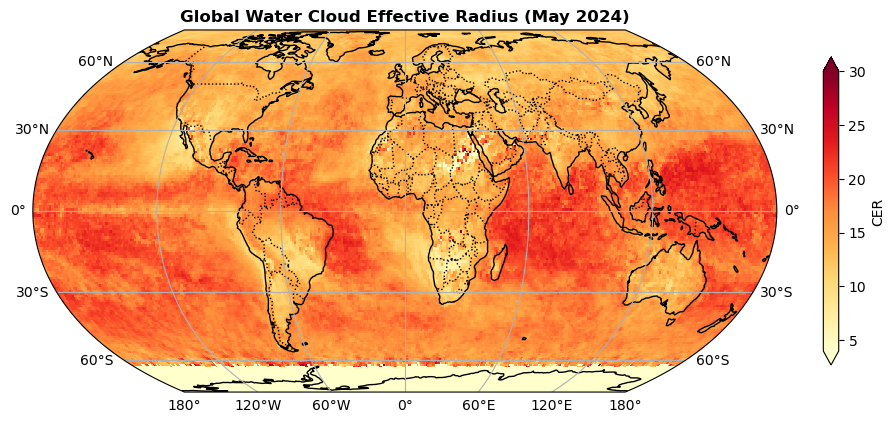

In [4]:
# Load HDF4 file
mod_data = 'MOD08_M3.A2024122.061.2024162163356.hdf'
my_data = SD(mod_data, SDC.READ)
mydata_SDSs= my_data.datasets()
# for idx, sds in enumerate(mydata_SDSs.keys()):
#     print(idx,sds)

sds_attr1 = my_data.select('Cloud_Effective_Radius_Liquid_Mean_Mean')      
# pprint.pprint(sds_attr1.attributes())

cer = my_data.select('Cloud_Effective_Radius_Liquid_Mean_Mean')   
cer_data = cer.get()

m_scal = my_data.select('Cloud_Effective_Radius_Liquid_Mean_Mean')
m_scal_val = m_scal.get()
attributes = cer.attributes()
scale = attributes.get('scale_factor')
print('scale factor:', scale)

rgb = np.zeros((203,135,1))
cer1 = cer_data*scale
print('Max and Min CER is:', np.max(cer1), np.min(cer1))

lat = np.arange(90,-91,-1)
lon = np.arange(-180,181)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.EqualEarth())

img = ax.pcolormesh(lon, lat, cer1, shading="nearest", rasterized=True, transform=ccrs.PlateCarree(), cmap='YlOrRd', 
                    vmin=4, vmax=30,) 

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Global Water Cloud Effective Radius (May 2024)', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False

cbar= plt.colorbar(img, ax=ax, shrink=0.5, extend='both')    
cbar.set_label('CER')

# plt.tight_layout()
# plt.savefig('CER.png', dpi=500, bbox_inches="tight")
plt.show()

scale factor: 9.999999747378752e-05
Max and Min Cf are: 0.9999999747378752 0.0017999999545281753


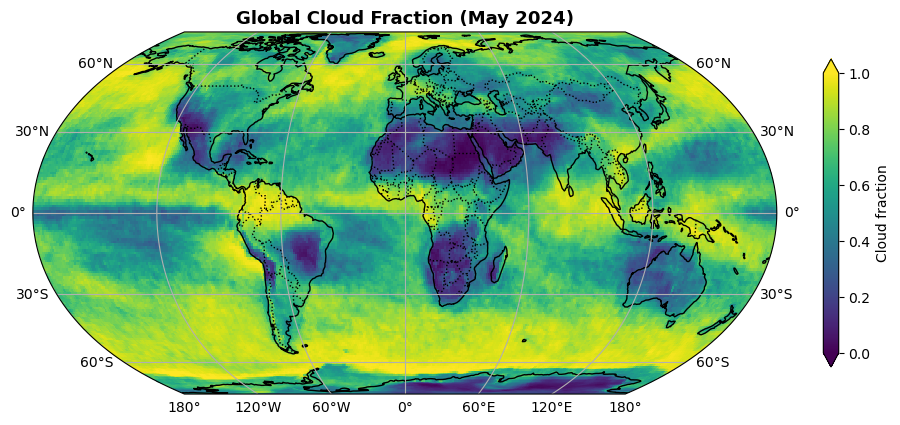

In [5]:
# Load HDF4 file
mod_data = 'MOD08_M3.A2024122.061.2024162163356.hdf'
my_data = SD(mod_data, SDC.READ)
mydata_SDSs= my_data.datasets()
# for idx, sds in enumerate(mydata_SDSs.keys()):
#     print(idx,sds)

sds_attr1 = my_data.select('Cloud_Fraction_Mean_Mean')      
# pprint.pprint(sds_attr1.attributes())

cf = my_data.select('Cloud_Fraction_Mean_Mean')   
cf_data = cf.get()

m_scal = my_data.select('Cloud_Fraction_Mean_Mean')
m_scal_val = m_scal.get()
attributes = cf.attributes()
scale = attributes.get('scale_factor')
print('scale factor:', scale)

rgb = np.zeros((203,135,1))
cf1 = cf_data*scale
print('Max and Min Cf are:', np.max(cf1), np.min(cf1))

lat = np.arange(90,-91,-1)
lon = np.arange(-180,181)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.EqualEarth())

img = ax.pcolormesh(lon, lat, cf1, shading="nearest", rasterized=True, transform=ccrs.PlateCarree(), cmap='viridis',
                    vmin=0, vmax=1,) 

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Global Cloud Fraction (May 2024)', fontsize=13, color='k', fontweight='bold')

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False

cbar= plt.colorbar(img, ax=ax, shrink=0.5, extend='both')    # orientation='horizontal',
cbar.set_label('Cloud fraction')

# plt.savefig('Cf.png', dpi=500, bbox_inches="tight")
plt.show()

scale factor: 1.0
Max and Min LWP is: 2753.0 -9999.0


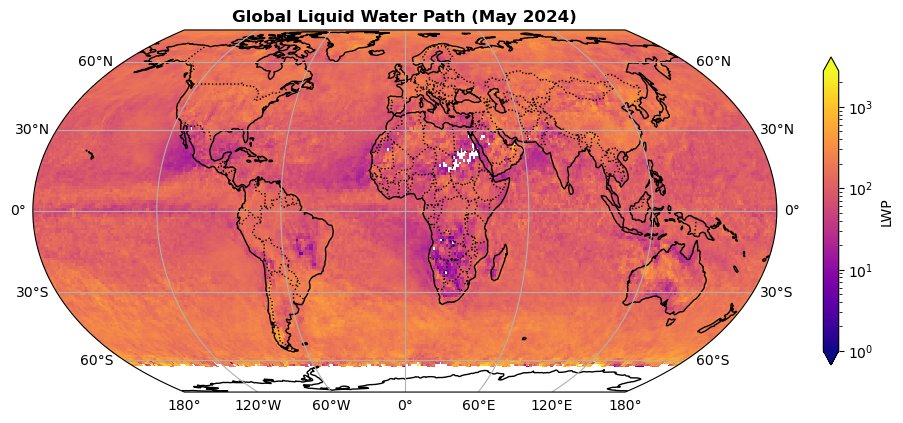

In [6]:
mod_data = 'MOD08_M3.A2024122.061.2024162163356.hdf'
my_data = SD(mod_data, SDC.READ)
mydata_SDSs= my_data.datasets()
# for idx, sds in enumerate(mydata_SDSs.keys()):
#     print(idx,sds)

sds_attr1 = my_data.select('Cloud_Water_Path_Liquid_Mean_Mean')      
# pprint.pprint(sds_attr1.attributes())

lwp = my_data.select('Cloud_Water_Path_Liquid_Mean_Mean')   
lwp_data = lwp.get()

m_scal = my_data.select('Cloud_Water_Path_Liquid_Mean_Mean')
m_scal_val = m_scal.get()
attributes = lwp.attributes()
scale = attributes.get('scale_factor')
print('scale factor:', scale)

rgb = np.zeros((203,135,1))
lwp1 = lwp_data*scale
print('Max and Min LWP is:', np.max(lwp1), np.min(lwp1))

lat = np.arange(90,-91,-1)
lon = np.arange(-180,181)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.EqualEarth())

img = ax.pcolormesh(lon, lat, lwp1, shading="nearest", rasterized=True, transform=ccrs.PlateCarree(), cmap='plasma', 
                    norm=LogNorm(vmin=10, vmax=300),)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Global Liquid Water Path (May 2024)', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False

cbar= plt.colorbar(img, ax=ax, shrink=0.5, extend='both')    
cbar.set_label('LWP')

# plt.savefig('LWP.png', dpi=500, bbox_inches="tight")
plt.show()

scale factor: 1.0
Max and Min LWP (1621) is: 493.0 -9999.0


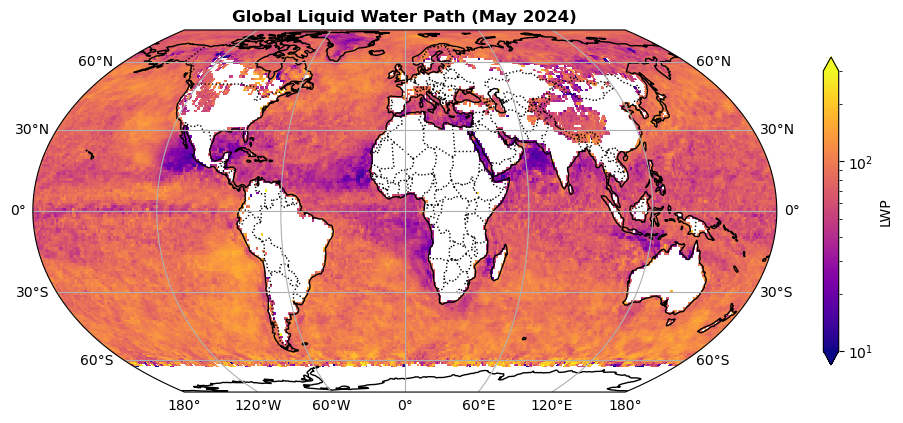

In [7]:
mod_data = 'MOD08_M3.A2024122.061.2024162163356.hdf'
my_data = SD(mod_data, SDC.READ)
mydata_SDSs= my_data.datasets()
# for idx, sds in enumerate(mydata_SDSs.keys()):
#     print(idx,sds)

sds_attr1 = my_data.select('Cloud_Water_Path_1621_Liquid_Mean_Mean')      
# pprint.pprint(sds_attr1.attributes())

lwp = my_data.select('Cloud_Water_Path_1621_Liquid_Mean_Mean')   
lwp_data = lwp.get()

m_scal = my_data.select('Cloud_Water_Path_1621_Liquid_Mean_Mean')
m_scal_val = m_scal.get()
attributes = lwp.attributes()
scale = attributes.get('scale_factor')
print('scale factor:', scale)

rgb = np.zeros((203,135,1))
lwp1 = lwp_data*scale
print('Max and Min LWP (1621) is:', np.max(lwp1), np.min(lwp1))

lat = np.arange(90,-91,-1)
lon = np.arange(-180,181)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.EqualEarth())

img = ax.pcolormesh(lon, lat, lwp1, shading="nearest", rasterized=True, transform=ccrs.PlateCarree(), cmap='plasma', 
                    norm=LogNorm(vmin=10, vmax=300),) 

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Global Liquid Water Path (May 2024)', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False

cbar= plt.colorbar(img, ax=ax, shrink=0.5, extend='both')    
cbar.set_label('LWP')

# plt.savefig('LWP_1621.png', dpi=500, bbox_inches="tight")
plt.show()

scale factor: 0.009999999776482582
Max and Min COT is: 149.99999664723873 -99.98999776504934


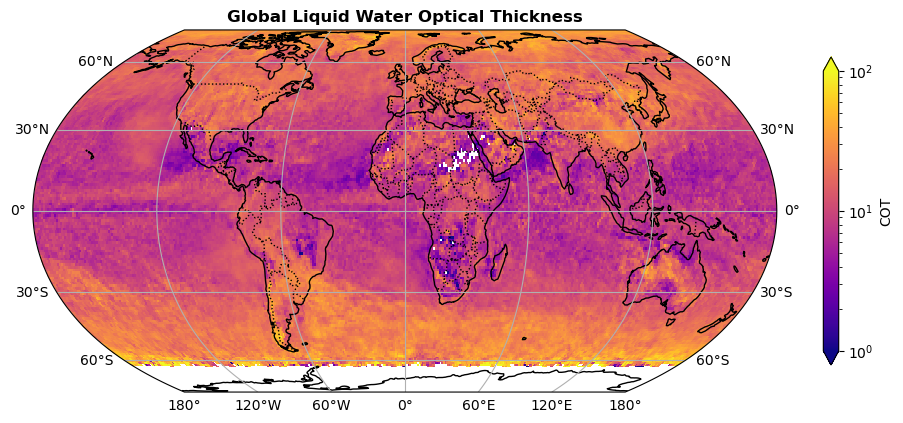

In [8]:
mod_data = 'MOD08_M3.A2024122.061.2024162163356.hdf'
my_data = SD(mod_data, SDC.READ)
mydata_SDSs= my_data.datasets()
# for idx, sds in enumerate(mydata_SDSs.keys()):
#     print(idx,sds)

sds_attr1 = my_data.select('Cloud_Optical_Thickness_Liquid_Mean_Mean')      
# pprint.pprint(sds_attr1.attributes())

cot = my_data.select('Cloud_Optical_Thickness_Liquid_Mean_Mean')   
cot_data = cot.get()

m_scal = my_data.select('Cloud_Optical_Thickness_Liquid_Mean_Mean')
m_scal_val = m_scal.get()
attributes = cot.attributes()
scale = attributes.get('scale_factor') 
print('scale factor:', scale)

rgb = np.zeros((203,135,1))
cot1 = cot_data*scale
print('Max and Min COT is:', np.max(cot1), np.min(cot1))

lat = np.arange(90,-91,-1)
lon = np.arange(-180,181)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.EqualEarth())

img = ax.pcolormesh(lon, lat, cot1, shading="nearest", rasterized=True, transform=ccrs.PlateCarree(), cmap='plasma', 
                    norm=LogNorm(vmin=1, vmax=100),) 

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Global Liquid Water Optical Thickness', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False

cbar= plt.colorbar(img, ax=ax, shrink=0.5, extend='both')    
cbar.set_label('COT')

# plt.savefig('COT.png', dpi=500, bbox_inches="tight")
plt.show()

scale factor: 0.10000000149011612
Max and Min CTP is: 983.0000146478415 224.5000033453107


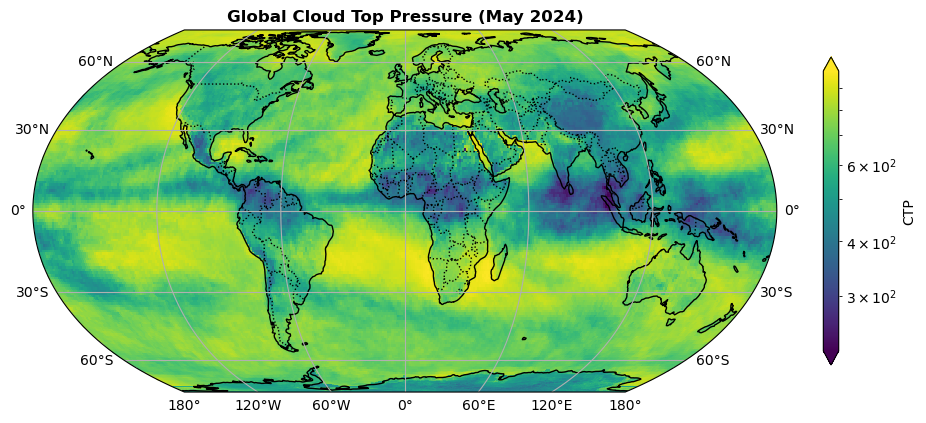

In [8]:
mod_data = 'MOD08_M3.A2024122.061.2024162163356.hdf'
my_data = SD(mod_data, SDC.READ)
mydata_SDSs= my_data.datasets()
# for idx, sds in enumerate(mydata_SDSs.keys()):
#     print(idx,sds)

sds_attr1 = my_data.select('Cloud_Top_Pressure_Mean_Mean')      
# pprint.pprint(sds_attr1.attributes())

ctp = my_data.select('Cloud_Top_Pressure_Mean_Mean')   
ctp_data = ctp.get()

m_scal = my_data.select('Cloud_Top_Pressure_Mean_Mean')
m_scal_val = m_scal.get()
attributes = ctp.attributes()
scale = attributes.get('scale_factor') 
print('scale factor:', scale)

rgb = np.zeros((203,135,1))
ctp1 = ctp_data*scale
print('Max and Min CTP is:', np.max(ctp1), np.min(ctp1))

lat = np.arange(90,-91,-1)
lon = np.arange(-180,181)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.EqualEarth())

img = ax.pcolormesh(lon, lat, ctp1, shading="nearest", rasterized=True, transform=ccrs.PlateCarree(), cmap='viridis', 
                    norm=LogNorm(),) 

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Global Cloud Top Pressure (May 2024)', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False

cbar= plt.colorbar(img, ax=ax, shrink=0.5, extend='both')    
cbar.set_label('CTP')

plt.show()

scale factor: 1.0
Max and Min CTP is: 13032.0 490.0


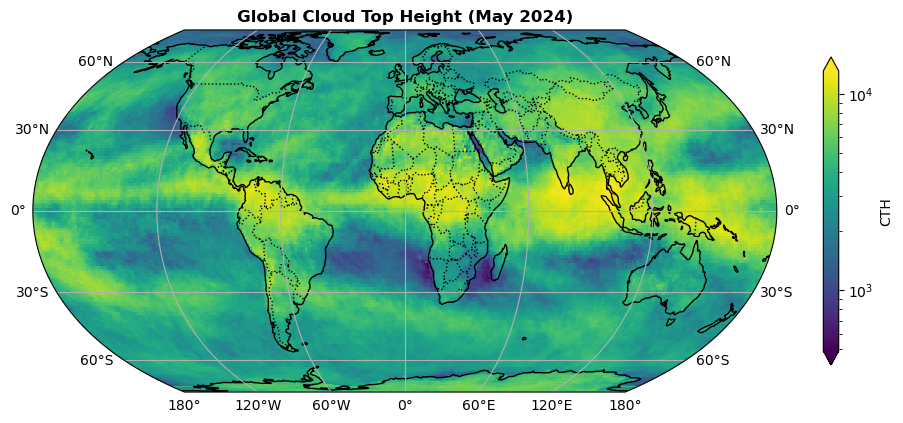

In [9]:
mod_data = 'MOD08_M3.A2024122.061.2024162163356.hdf'
my_data = SD(mod_data, SDC.READ)
mydata_SDSs= my_data.datasets()
# for idx, sds in enumerate(mydata_SDSs.keys()):
#     print(idx,sds)

sds_attr1 = my_data.select('Cloud_Top_Height_Mean_Mean')      
# pprint.pprint(sds_attr1.attributes())

cth = my_data.select('Cloud_Top_Height_Mean_Mean')   
cth_data = cth.get()

m_scal = my_data.select('Cloud_Top_Height_Mean_Mean')
m_scal_val = m_scal.get()
attributes = cth.attributes()
scale = attributes.get('scale_factor') 
print('scale factor:', scale)

rgb = np.zeros((203,135,1))
cth1 = cth_data*scale
print('Max and Min CTP is:', np.max(cth1), np.min(cth1))

lat = np.arange(90,-91,-1)
lon = np.arange(-180,181)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.EqualEarth())

img = ax.pcolormesh(lon, lat, cth1, shading="nearest", rasterized=True, transform=ccrs.PlateCarree(), cmap='viridis', 
                    norm=LogNorm(),)      # vmin=490, vmax=13000

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Global Cloud Top Height (May 2024)', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False

cbar= plt.colorbar(img, ax=ax, shrink=0.5, extend='both')    
cbar.set_label('CTH')

# tick_values_m = np.array([500, 1000, 2000, 5000, 10000, 13000])   
# tick_labels_km = [f"{v/1e3:.0f}" for v in tick_values_m]  # convert m → km
# cbar.set_ticks(tick_values_m)
# cbar.set_ticklabels(tick_labels_km) 

plt.show()

### Cut a Lat/Lon box

In [14]:
print(aod1.shape)                 # contains (lat, lon) = (180, 360)
lat = np.arange(90,-91,-1)
lon = np.arange(-180,181)

# print(lat[90:90+36])
# print(lon[185:236])

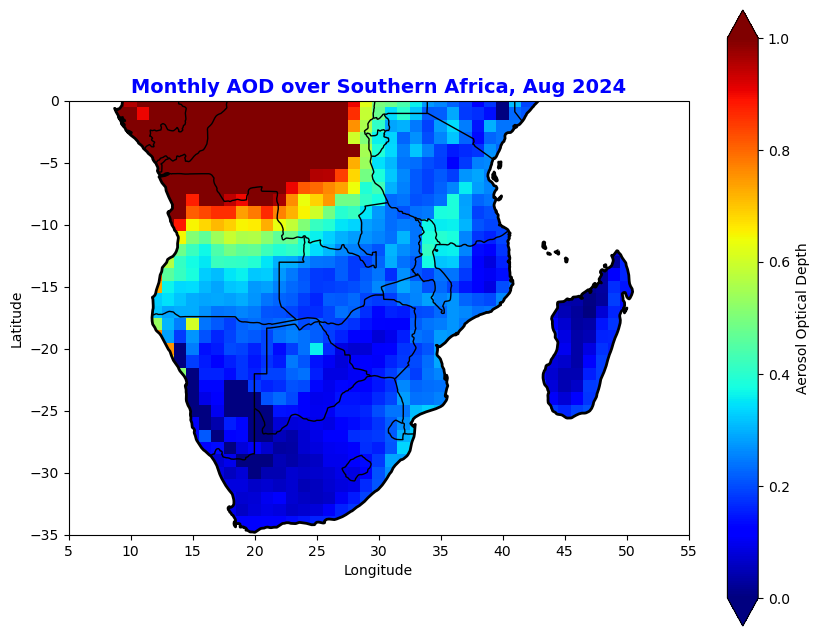

In [4]:
lon_min, lon_max = 5, 55
lat_min, lat_max = -35, 0

fig, ax = plt.subplots(figsize=(10,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

img = ax.pcolormesh(lon[185:236], lat[90:90+36], aod1[90:90+36,185:236], transform=ccrs.PlateCarree(), 
                    vmin=0, vmax=1, cmap='jet')
ax.add_feature(cfeature.COASTLINE, linewidth=2, edgecolor='black') 
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle="-", linewidth=1)
ax.set_xticks(np.arange(lon_min, lon_max + 5, 5), crs=ccrs.PlateCarree())  
ax.set_yticks(np.arange(lat_min, lat_max + 5, 5), crs=ccrs.PlateCarree())
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title('Monthly AOD over Southern Africa, Aug 2024', fontsize=14, color='b', fontweight='bold')

cbar= plt.colorbar(img, ax=ax, shrink=0.5, extend='both')    
cbar.set_label('AOD')

# plt.savefig('AOD_Aug.png', dpi=300)
plt.show()

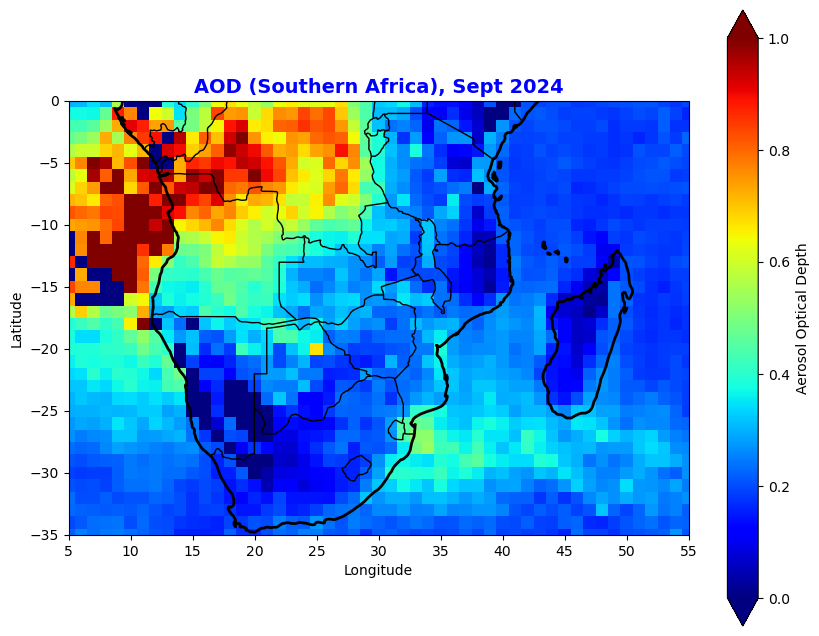

In [6]:
fig, ax = plt.subplots(figsize=(10,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

img = ax.pcolormesh(lon[185:236], lat[90:90+36], aod1[90:90+36,185:236], transform=ccrs.PlateCarree(), 
                    vmin=0, vmax=1, cmap='jet')
ax.add_feature(cfeature.COASTLINE, linewidth=2, edgecolor='black') 
# ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle="-", linewidth=1)
ax.set_xticks(np.arange(lon_min, lon_max + 5, 5), crs=ccrs.PlateCarree())  
ax.set_yticks(np.arange(lat_min, lat_max + 5, 5), crs=ccrs.PlateCarree())
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title('AOD (Southern Africa), Sept 2024', fontsize=14, color='b', fontweight='bold')

cbar= plt.colorbar(img, ax=ax, shrink=0.5, extend='both')    
cbar.set_label('AOD')

plt.show()